# Programar Raspberry pi pico desde COLAB


![](https://projects-static.raspberrypi.org/projects/getting-started-with-the-pico/991cb74a9ee566023ff2811e49fe0447d80966db/en/images/Pico-R3-Pinout.png)

## Descargar arduino-cli

https://github.com/earlephilhower/arduino-pico

In [1]:
!curl -fsSL https://raw.githubusercontent.com/arduino/arduino-cli/master/install.sh | sh


Installing in /content/bin
ARCH=64bit
OS=Linux
Using curl as download tool
install.sh: arduino-cli not found. You might want to add "/content/bin" to your $PATH
arduino-cli  Version: 1.5.1 Commit: 01f3d4f2b Date: 2026-06-05T10:22:17Z installed successfully in /content/bin


In [2]:
!cp /content/bin/arduino-cli ./

In [3]:
!./arduino-cli

Arduino Command Line Interface (arduino-cli).

Usage:
  arduino-cli [command]

Examples:
  ./arduino-cli <command> [flags...]

Available Commands:
  board           Arduino board commands.
  burn-bootloader Upload the bootloader.
  cache           Arduino cache commands.
  compile         Compiles Arduino sketches.
  completion      Generates completion scripts
  config          Arduino configuration commands.
  core            Arduino core operations.
  daemon          Run the Arduino CLI as a gRPC daemon.
  debug           Debug Arduino sketches.
  help            Help about any command
  lib             Arduino commands about libraries.
  monitor         Open a communication port with a board.
  outdated        Lists cores and libraries that can be upgraded
  profile         Build profile operations.
  sketch          Arduino CLI sketch commands.
  update          Updates the index of cores and libraries
  upgrade         Upgrades installed cores and libraries.
  upload          Upl

In [4]:
# Crea un archivo de configuración básico
!./arduino-cli config init

# Añade la URL del núcleo de la Raspberry Pi Pico
!./arduino-cli config add board_manager.additional_urls https://github.com/earlephilhower/arduino-pico/releases/download/global/package_rp2040_index.json

# Actualiza el índice
!./arduino-cli core update-index

# Instala el núcleo de la Pico
!./arduino-cli core install rp2040:rp2040

Config file written to: /root/.arduino15/arduino-cli.yaml
builtin:ctags@5.8-arduino11 downloaded
Installing builtin:ctags@5.8-arduino11...
Skipping tool configuration....
builtin:ctags@5.8-arduino11 installed
builtin:dfu-discovery@0.1.2 downloaded
Installing builtin:dfu-discovery@0.1.2...
Skipping tool configuration....
builtin:dfu-discovery@0.1.2 installed
builtin:mdns-discovery@1.0.12 downloaded
Installing builtin:mdns-discovery@1.0.12...
Skipping tool configuration....
builtin:mdns-discovery@1.0.12 installed
builtin:serial-discovery@1.4.3 downloaded
Installing builtin:serial-discovery@1.4.3...
Skipping tool configuration....
builtin:serial-discovery@1.4.3 installed
builtin:serial-monitor@0.15.0 downloaded
Installing builtin:serial-monitor@0.15.0...
Skipping tool configuration....
builtin:serial-monitor@0.15.0 installed
rp2040:pqt-gcc@4.1.0-1aec55e downloaded
rp2040:pqt-gcc-riscv@4.1.0-1aec55e downloaded
rp2040:pqt-mklittlefs@4.1.0-1aec55e downloaded
rp2040:pqt-pioasm@4.1.0-1aec55e d

## Crear proyecto de arduino

Es necesario crear la carpeta del proyecto de arduino SOLO LA PRIMERA VEZ

In [5]:
!mkdir test

### Toda actualización del código deberia empezar desde esta celda


---



In [6]:
%%writefile ./test/test.ino

void setup() {
  // put your setup code here, to run once:
  Serial1.begin(115200);
  Serial1.println("Hello, from UPCH");
}

void loop() {
  // put your main code here, to run repeatedly:
  delay(1); // this speeds up the simulation
}




Writing ./test/test.ino


### Compilar el código de forma básica

In [7]:
!./arduino-cli compile --fqbn rp2040:rp2040:rpipico test

Sketch uses 55412 bytes (2%) of program storage space. Maximum is 2093056 bytes.
Global variables use 9152 bytes (3%) of dynamic memory, leaving 252992 bytes for local variables. Maximum is 262144 bytes.


### Compilar el código para obtener el uf2

In [8]:
!./arduino-cli compile --fqbn rp2040:rp2040:rpipico --export-binaries test

Sketch uses 55412 bytes (2%) of program storage space. Maximum is 2093056 bytes.
Global variables use 9152 bytes (3%) of dynamic memory, leaving 252992 bytes for local variables. Maximum is 262144 bytes.


## Desde WOKWI seleccionar un proyecto con raspberry pi pico, luego apretar F1 y colocar "Upload firmware and starts simulation"

Wokwi utiza el Serial1 para imprimir en el monitor serial

https://wokwi.com/projects/new/pi-pico

Puedes probar directamente con el firmware de aquí:
[LINK DESCARGA](https://github.com/MSMRo/TINYML-PICO2-SIGNALS/raw/refs/heads/main/FIRMWARES/test.ino.uf2)


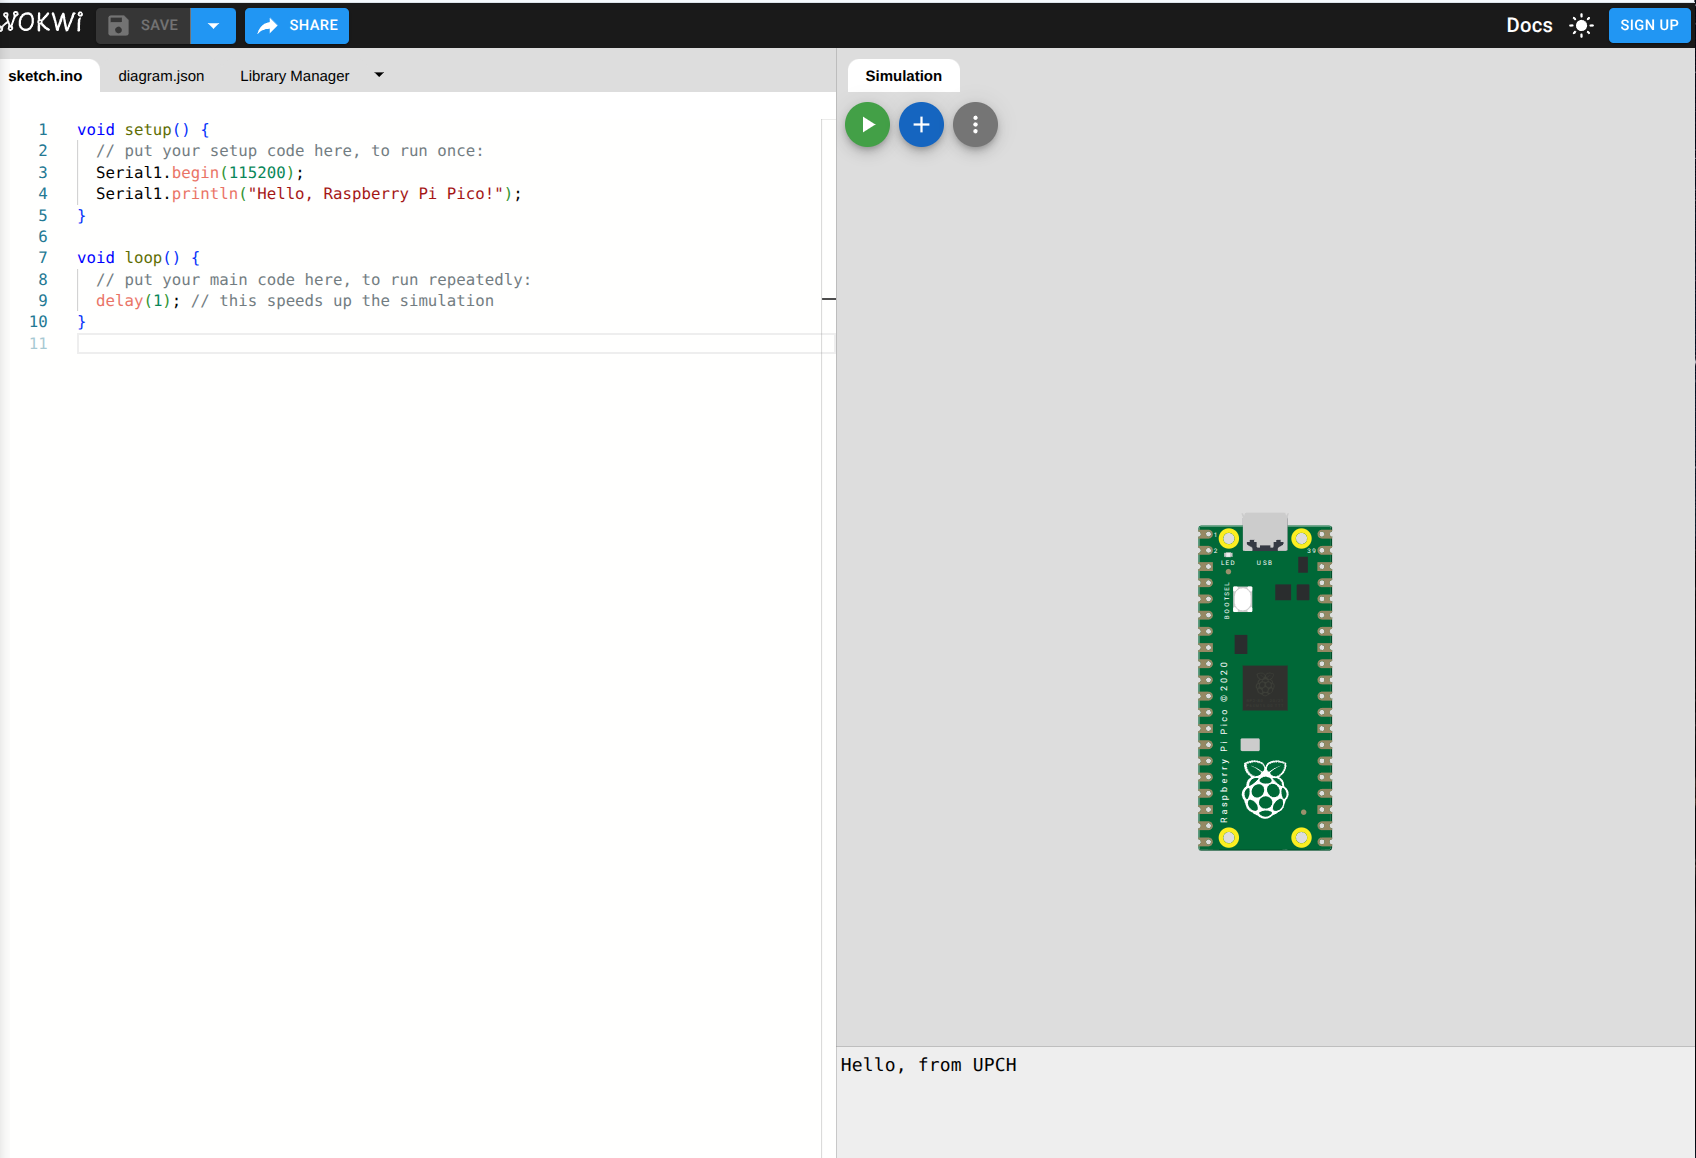

Para subir el firmware debes precionar ```F1``` y buscar  **Upload firmware ....**

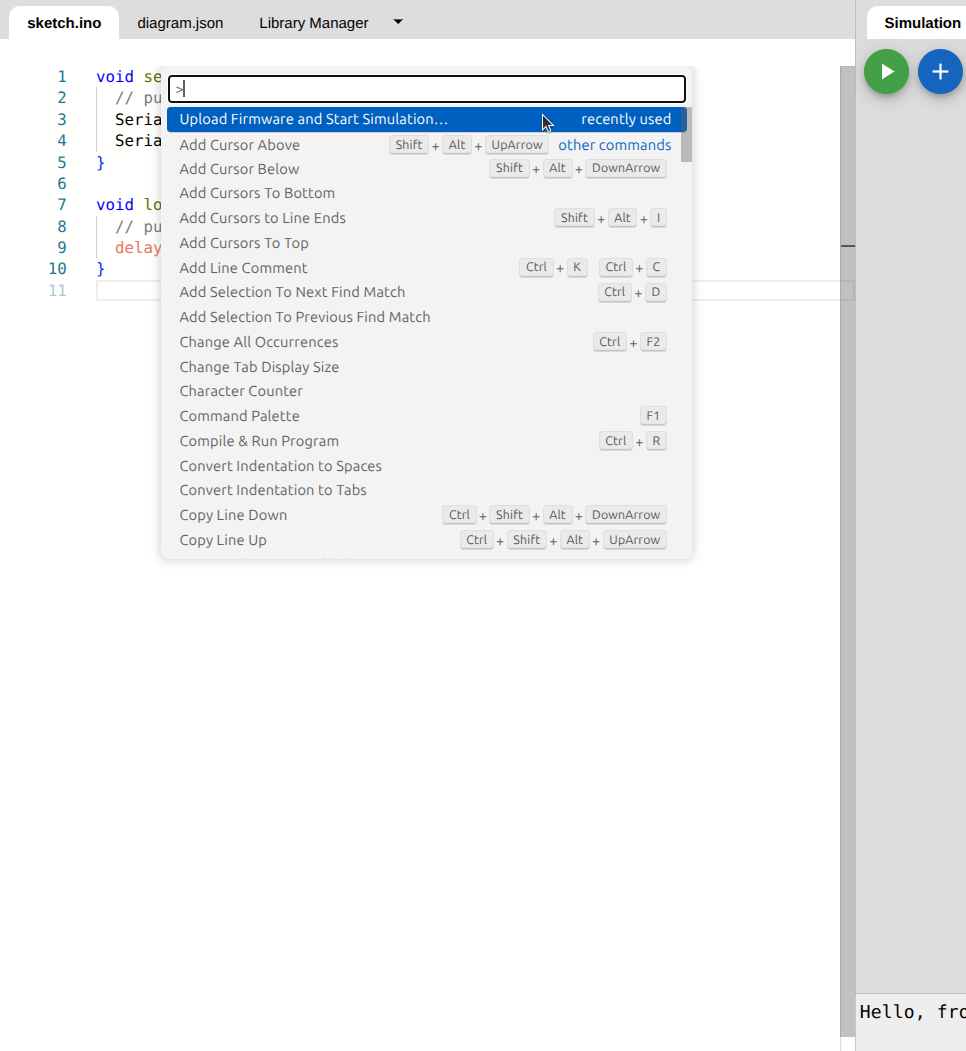

## **Subir un código con modelo de TFLITE en la Pi PICO**

In [9]:
!mkdir TEST_TFLITE1

El modelo fue generado aqui: https://colab.research.google.com/drive/1v5MyUY8FHqm7rpP6NtgZ-m6fqvky_qV9?usp=sharing

Luego fue subido a un github, donde debemos descargar el modelo ```.h``` para poder compilar el código arduino

In [18]:
!wget -O ./TEST_TFLITE1/model_2_categories.h \
https://raw.githubusercontent.com/MSMRo/TINYML-PICO2-SIGNALS/refs/heads/main/MODELOS_H/model_2_categories.h

--2026-06-30 15:13:08--  https://raw.githubusercontent.com/MSMRo/TINYML-PICO2-SIGNALS/refs/heads/main/MODELOS_H/model_2_categories.h
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 21258 (21K) [text/plain]
Saving to: ‘./TEST_TFLITE1/model_2_categories.h’

./TEST_TFLITE1/mode 100%[===================>]  20.76K  --.-KB/s    in 0s      

2026-06-30 15:13:08 (99.8 MB/s) - ‘./TEST_TFLITE1/model_2_categories.h’ saved [21258/21258]



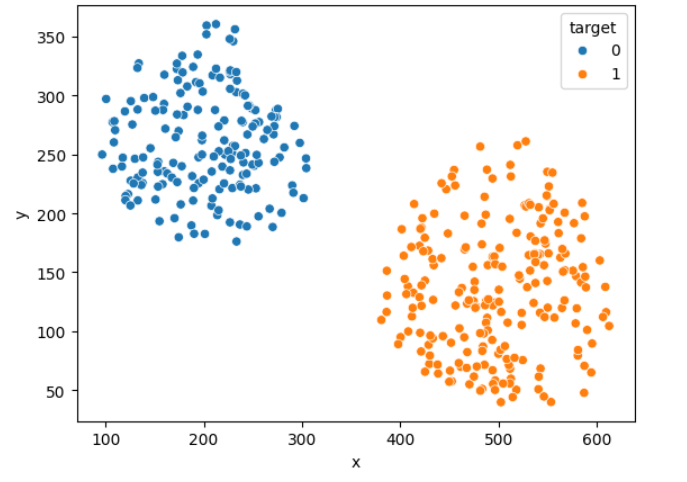

El modelo predice una salida binaria dependiendo de 2 features ```x```  e ```y``` que en arduino serán representados por el ```ADC0 (pin 26)``` y ```ADC1 (pin 27)```

In [26]:
%%writefile ./TEST_TFLITE1/TEST_TFLITE1.ino

#include <Arduino.h>
#include "model_2_categories.h"
#include <ArduTFLite.h>

constexpr int tensorArenaSize = 8 * 1024;
alignas(16) byte tensorArena[tensorArenaSize];

void setup() {
  // put your setup code here, to run once:
  Serial1.begin(115200);
  Serial1.println("Mi primer modelo de TinyML");
  analogReadResolution(10);

  //pinMode(led_blue, OUTPUT);
  //digitalWrite(led_blue, LOW);

  if (!modelInit(model_2_categories_tflite, tensorArena, tensorArenaSize)){
    Serial1.println("Model initialization failed!");
    while(true);
  }
  Serial1.println("Model initialization done.");
}

void loop() {
 float v1 = analogRead(26);
 float v2 = analogRead(27);

 v1 = map(v1, 0, 1023, 0, 650);
 v2 = map(v2, 0, 1023, 0, 400);

 Serial1.print("ADC0(x),ADC1(y):");
 Serial1.print(v1);
 Serial1.print(" , ");
 Serial1.println(v2);

modelSetInput(v1,0);
modelSetInput(v2,1);

if(!modelRunInference()){
    Serial1.println("RunInference Failed!");
    return;
}
float result = modelGetOutput(0);
Serial1.println(result);

 delay(500);
}

Overwriting ./TEST_TFLITE1/TEST_TFLITE1.ino


## Instalar librerias de TFLITE

In [20]:
!./arduino-cli lib list

Name                   Installed     Available    Location Description
Arduino_TensorFlowLite 2.4.0-ALPHA   -            user     -
ArduTFLite             1.0.2         -            user     -
Chirale_TensorFLowLite 2.0.0         -            user     -



In [11]:
# 1. Habilitar la instalación desde orígenes externos (ZIP o Git)
!./arduino-cli config set library.enable_unsafe_install true

In [13]:
!mkdir -p ./LIBRERIAS_ARDUINO

In [14]:
!wget -O ./LIBRERIAS_ARDUINO/Arduino_TensorFlowLite.zip \
"https://github.com/MSMRo/TINYML-PICO2-SIGNALS/raw/refs/heads/main/LIBRERIAS_ARDUINO_TINYML/Arduino_TensorFlowLite.zip"

!wget -O ./LIBRERIAS_ARDUINO//ArduTFLite-main.zip \
"https://github.com/MSMRo/TINYML-PICO2-SIGNALS/raw/refs/heads/main/LIBRERIAS_ARDUINO_TINYML//ArduTFLite-main.zip"

!wget -O ./LIBRERIAS_ARDUINO/Chirale_TensorFlowLite-main.zip \
"https://github.com/MSMRo/TINYML-PICO2-SIGNALS/raw/refs/heads/main/LIBRERIAS_ARDUINO_TINYML/Chirale_TensorFlowLite-main.zip"

--2026-06-30 14:57:30--  https://github.com/MSMRo/TINYML-PICO2-SIGNALS/raw/refs/heads/main/LIBRERIAS_ARDUINO_TINYML/Arduino_TensorFlowLite.zip
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://media.githubusercontent.com/media/MSMRo/TINYML-PICO2-SIGNALS/refs/heads/main/LIBRERIAS_ARDUINO_TINYML/Arduino_TensorFlowLite.zip [following]
--2026-06-30 14:57:30--  https://media.githubusercontent.com/media/MSMRo/TINYML-PICO2-SIGNALS/refs/heads/main/LIBRERIAS_ARDUINO_TINYML/Arduino_TensorFlowLite.zip
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 74348684 (71M) [application/zip]
Saving to: ‘./LIBRERIAS_ARDUINO/Arduino_Tenso

In [15]:
!./arduino-cli lib install --zip-path /content/LIBRERIAS_ARDUINO/Arduino_TensorFlowLite.zip
!./arduino-cli lib install --zip-path /content/LIBRERIAS_ARDUINO/ArduTFLite-main.zip
!./arduino-cli lib install --zip-path /content/LIBRERIAS_ARDUINO/Chirale_TensorFlowLite-main.zip

--git-url and --zip-path flags allow installing untrusted files, use it at your own risk.
Library installed
--git-url and --zip-path flags allow installing untrusted files, use it at your own risk.
Library installed
--git-url and --zip-path flags allow installing untrusted files, use it at your own risk.
Library installed


In [16]:
!./arduino-cli lib list

Name                   Installed     Available    Location Description
Arduino_TensorFlowLite 2.4.0-ALPHA   -            user     -
ArduTFLite             1.0.2         -            user     -
Chirale_TensorFLowLite 2.0.0         -            user     -



Puede tomar alrededor de 10 min  compilar

In [27]:
!./arduino-cli compile --fqbn rp2040:rp2040:rpipico --export-binaries TEST_TFLITE1

Sketch uses 294880 bytes (14%) of program storage space. Maximum is 2093056 bytes.
Global variables use 23732 bytes (9%) of dynamic memory, leaving 238412 bytes for local variables. Maximum is 262144 bytes.


Test del modelo en Wokwi:

https://wokwi.com/projects/467953913992595457

Puedes probar con el firmware uf2 del github:
[LINK DESCARGA](https://github.com/MSMRo/TINYML-PICO2-SIGNALS/raw/refs/heads/main/FIRMWARES/TEST_TFLITE1.ino.uf2)

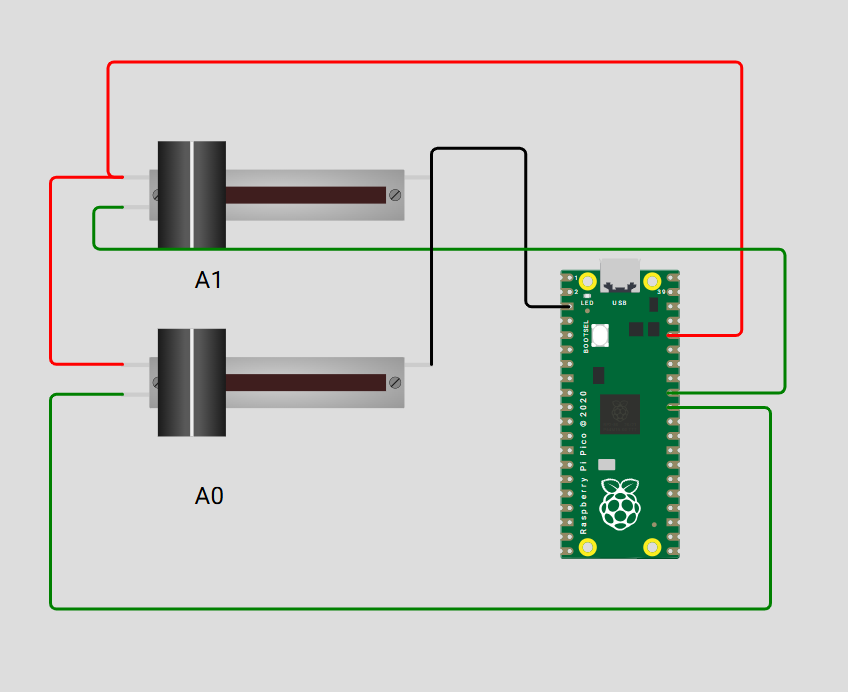

## Modificar el código

In [ ]:
%%writefile ./TEST_TFLITE1/TEST_TFLITE1.ino

#include <Arduino.h>
#include "model_2_categories.h"
#include <ArduTFLite.h>

constexpr int tensorArenaSize = 8 * 1024;
alignas(16) byte tensorArena[tensorArenaSize];

void setup() {
  // put your setup code here, to run once:
  Serial1.begin(115200);
  Serial1.println("Mi primer modelo de TinyML");
  analogReadResolution(10);

  //pinMode(led_blue, OUTPUT);
  //digitalWrite(led_blue, LOW);

  if (!modelInit(model_2_categories_tflite, tensorArena, tensorArenaSize)){
    Serial1.println("Model initialization failed!");
    while(true);
  }
  Serial1.println("Model initialization done.");
}

void loop() {
 float v1 = analogRead(26);
 float v2 = analogRead(27);

 v1 = map(v1, 0, 1023, 0, 650);
 v2 = map(v2, 0, 1023, 0, 400);

 Serial1.print("ADC0(x),ADC1(y):");
 Serial1.print(v1);
 Serial1.print(" , ");
 Serial1.println(v2);

modelSetInput(v1,0);
modelSetInput(v2,1);

if(!modelRunInference()){
    Serial1.println("RunInference Failed!");
    return;
}
float result = modelGetOutput(0);
Serial1.println(result);

 delay(500);
}

In [ ]:
!./arduino-cli compile --fqbn rp2040:rp2040:rpipico --export-binaries TEST_TFLITE1